In [1]:
%%capture
! pip install laspy

In [2]:
# Geospatial and mapping libraries
import geopandas as gpd

# LAS (LiDAR) file handling
import laspy
from laspy import read

# Data analysis and manipulation
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Warnings management
import warnings

# File system operations
import os

# Return type hints
from typing import Tuple, List

In [3]:
def load_and_filter_las(file_path: str, filter_class: int = 5) -> np.ndarray:
    """
    Load a .las file and return points filtered by classification.
    """
    try:
        las = laspy.read(file_path)
        mask = las.classification == filter_class
        points = np.stack([las.x[mask], las.y[mask], las.z[mask]], axis=1)
        return points
    except Exception as e:
        print(f"Error loading and filtering file: {e}")
        return None

In [4]:
def normalize_points(points)-> np.ndarray:
    """
    Normalize points to (0, 0, 0) by subtracting the minimum coordinates.
    """
    return points - points.min(axis=0, keepdims=True)


In [5]:
def plot_normalized_lidar(lidar_file: str):
    """
    Plot a 3D LiDAR point cloud with ground points in red and normalized coordinates.
    """
    try:
        las = laspy.read(lidar_file)
        points = np.stack([las.x, las.y, las.z], axis=1)
        classifications = las.classification

        # Normalize points to start from (0, 0, 0)
        points = normalize_points(points)
        ground_mask = classifications == 2
        ground_points = points[ground_mask]
        other_points = points[~ground_mask]

        file_name = os.path.splitext(os.path.basename(lidar_file))[0]

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")

        ax.scatter(
            ground_points[:, 0],
            ground_points[:, 1],
            ground_points[:, 2],
            c="red",
            s=0.5,
            label="Ground Points",
        )

        ax.scatter(
            other_points[:, 0],
            other_points[:, 1],
            other_points[:, 2],
            c=other_points[:, 2],
            cmap="viridis",
            s=0.5,
        )

        ax.set_title("LiDAR Point Cloud Visualization (Normalized)")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")

        ax.view_init(elev=30, azim=45)
        ax.legend(loc="upper right", markerscale=5, fontsize=10)

        plt.figtext(0.5, 0.01, f"{file_name}", ha="center", style="italic")

        plt.show()

    except Exception as e:
        print(f"Error visualizing LiDAR file: {e}")

In [6]:
def calculate_iqr_outliers(z_values: np.ndarray) -> Tuple[float, float]:
    """
    Calculate the lower and upper bounds for outliers in Z values based on the IQR method.
    """
    q1 = np.percentile(z_values, 25)  # 25th percentile (Q1)
    q3 = np.percentile(z_values, 75)  # 75th percentile (Q3)
    iqr = q3 - q1  # Interquartile range (IQR)

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return lower_bound, upper_bound

In [7]:
def plot_z_distribution(points: np.ndarray, ax, file_name: str):
    """
    Plot the Z-value distribution for the given points on a specific subplot, with outlier boundaries.
    """
    z_values = points[:, 2]

    lower_bound, upper_bound = calculate_iqr_outliers(z_values)

    # Plot histogram
    ax.hist(z_values, bins=50, color="green", alpha=0.7, label="Z Values")

    # Add IQR outlier lines
    ax.axvline(lower_bound, color="red", linestyle="--", label=f"Lower: {lower_bound:.2f}")
    ax.axvline(upper_bound, color="red", linestyle="--", label=f"Upper: {upper_bound:.2f}")

    ax.set_title(file_name, fontsize=10)
    ax.set_xlabel("Z Value (Height)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

In [8]:
def preprocess_data(points: np.ndarray) -> np.ndarray:
    """
    Preprocess LiDAR points by normalizing them and removing outliers based on the IQR method.
    """
    normalized_points = normalize_points(points)
    z_values = normalized_points[:, 2]
    lower_bound, upper_bound = calculate_iqr_outliers(z_values)
    mask = (z_values >= lower_bound) & (z_values <= upper_bound)

    filtered_points = normalized_points[mask]

    return filtered_points

In [9]:
def split_dataset(data: List, train_ratio: float = 0.7) -> Tuple[List, List]:
    """
    Splits the dataset into training and testing sets based on the given ratio.
    """
    split_idx = int(len(data) * train_ratio)

    train_data = data[:split_idx]
    test_data = data[split_idx:]

    return train_data, test_data

In [12]:
plot_las_files = [f"data/als/plot_{i:02d}.las" for i in range(1, 11)]


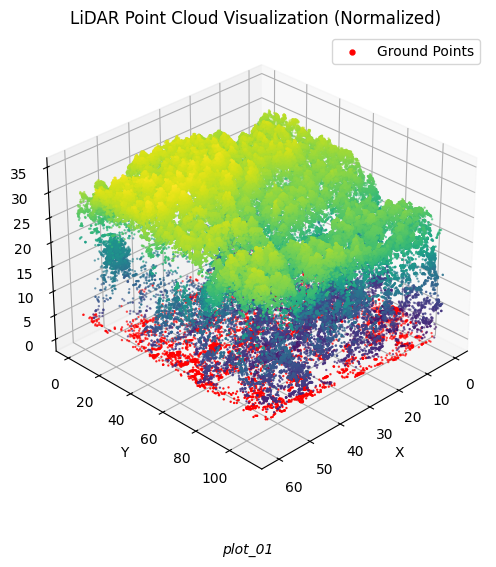

In [13]:
plot_normalized_lidar(plot_las_files[0])


Processing plot_01.las...
Processing plot_02.las...
Processing plot_03.las...
Processing plot_04.las...
Processing plot_05.las...
Processing plot_06.las...
Processing plot_07.las...
Processing plot_08.las...
Processing plot_09.las...
Processing plot_10.las...


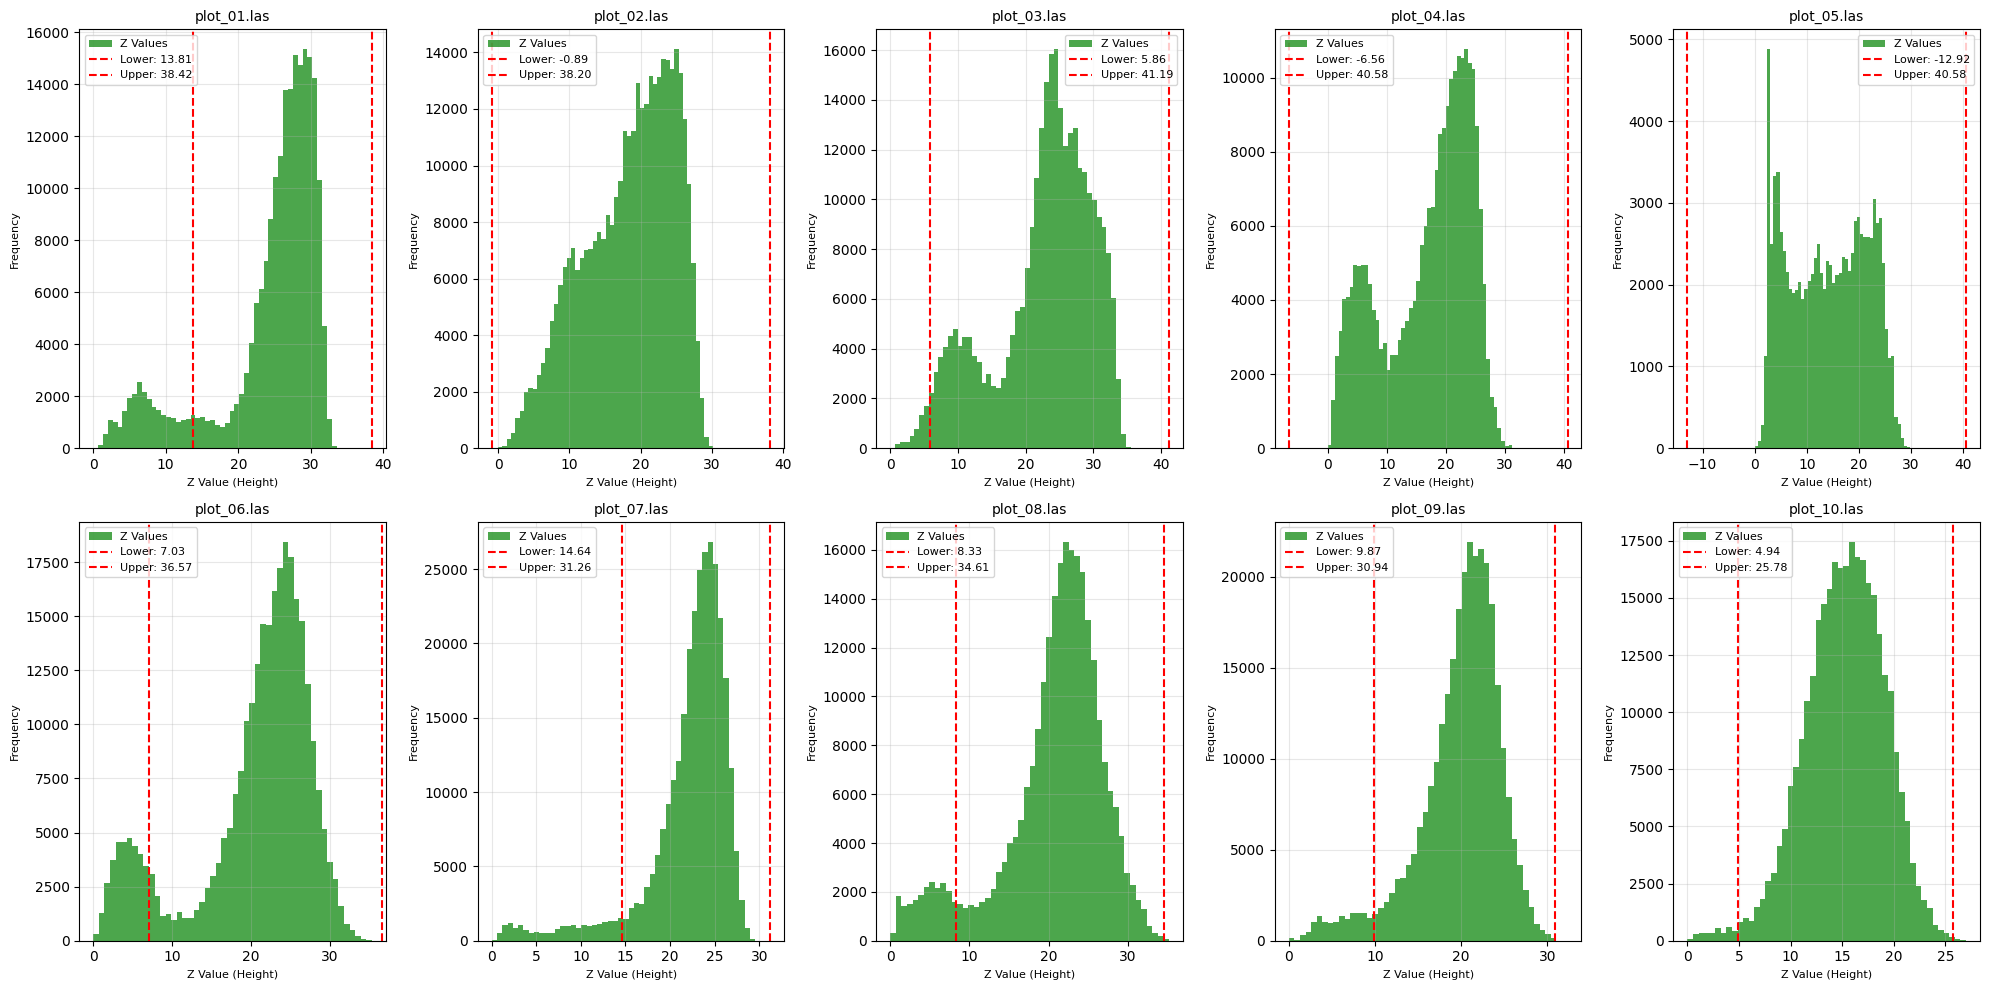

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, file_path in enumerate(plot_las_files[:10]):
    file_name = os.path.basename(file_path)
    print(f"Processing {file_name}...")

    # Load and filter points
    points = load_and_filter_las(file_path, filter_class=5)
    if points is None or len(points) == 0:
        print(f"Skipping {file_name} due to an error or no valid points.")
        continue

    normalized_points = normalize_points(points)

    plot_z_distribution(normalized_points, axes[i], file_name)


plt.tight_layout()
plt.show()

In [15]:
preprocessed_data = []

for file_path in plot_las_files:

    points = load_and_filter_las(file_path, filter_class=5)

    if points is not None and len(points) > 0:
        preprocessed_points = preprocess_data(points)
        preprocessed_data.append(preprocessed_points)

    else:
        print(f"Skipping {file_path} due to no valid points.")

for i, points in enumerate(preprocessed_data):
    print(f"File {i + 1}: {len(points)} preprocessed points")

File 1: 187731 preprocessed points
File 2: 350098 preprocessed points
File 3: 290624 preprocessed points
File 4: 241722 preprocessed points
File 5: 98878 preprocessed points
File 6: 255332 preprocessed points
File 7: 283645 preprocessed points
File 8: 234435 preprocessed points
File 9: 287338 preprocessed points
File 10: 307393 preprocessed points


In [62]:
len(test_data)

3

In [16]:
train_ratio = 0.7
train_data, test_data = split_dataset(preprocessed_data, train_ratio)


In [17]:
import numpy as np
import scipy.spatial
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import precision_score, recall_score, f1_score


In [50]:
from scipy.spatial import KDTree


In [71]:
def local_maxima_filter(cloud: np.ndarray, window_size: float | int, height_threshold: float | int) -> np.ndarray:
    """Detect local maxima in the point cloud with a fixed window size."""

    assert isinstance(cloud, np.ndarray), f"Cloud needs to be a numpy array, not {type(cloud)}"

    cloud = cloud[cloud[:, 2] > height_threshold]
    tree = scipy.spatial.KDTree(data=cloud)
    seen_mask = np.zeros(cloud.shape[0], dtype=bool)
    local_maxima = []

    for i, point in enumerate(cloud):
        if seen_mask[i]:
            continue
        neighbor_indices = tree.query_ball_point(point, window_size)
        highest_neighbor = neighbor_indices[cloud[neighbor_indices, 2].argmax()]
        seen_mask[neighbor_indices] = True
        seen_mask[highest_neighbor] = False
        # This may lead to not every point being marked as seed in the end, but it does not matter,
        # because by the time the seen value is overwritten the point is already processed
        if i == highest_neighbor:
            local_maxima.append(i)

    return cloud[local_maxima]

In [76]:
# Apply local maxima filtering to training data
all_train_points = np.vstack(train_data)  # Aggregate points from all files

# Apply the local maxima filter to the entire combined array
local_maxima_points = local_maxima_filter(all_train_points, 3, 0.5)

# Print the total number of detected local maxima
print(f"Detected {len(local_maxima_points)} local maxima points.")

Detected 314 local maxima points.
